# Formative - data analysis task 2024/2025

You have been given access to data on patients attending an opthalmology clinic for cataract surgery. 

The data contains pre-, intra- and post-operative data for patients (i.e. data measured before the operation, during the operation, and after the operation).

You are asked to predict those who are discharged from hospital within 24 hours of the operation (`discharge24`), using data available **at the conclusion of the operation**.
    
The folder on the VLE contains three files:
   * `training_data.csv` details of a subset of patients, with `discharge24` disclosed
   * `test_data.csv` details of a subset of patients with `discharge24` not disclosed
   * data_dictionary.gdoc - the data dictionary for these data.
   
You will need to pre-process the training and test datasets. You are asked to include a binary feature that represents whether a patient is overweight or not, based on body mass index (BMI). You should convert this continuous feature into a binary feature, using an appropriate threshold. 

You are asked to produce and compare **two** models for the task:
1. a decision tree model
2. a bagged ensemble model

Both models should be optimised your model on the training dataset using the **balanced accuracy score**  

The decision tree model is an interpretable model. Provide some **interpretability** of your bagged ensemble model. 

Based on your findings, choose one of your models to select as your final model. Provide a comment explaining your choice. 
   
Use your final model to predict the class label (i.e. predict `discharge24`) for those individuals in `test_data.csv`. **Save your predictions as** `y_predict`.

These predictions will be compared to `y_test` (i.e. the actual observed values for `discharge24`), which you do not have access to. The performance of your final model on the test data will contribute to your mark for this question.   

Your code should be commented, and you should also include text sections in your notebook providing additional background information and any references needed to explain your code.

The marking rubric is available here: https://docs.google.com/document/d/1OGZKaPKO61JOtGoPn_XT5bj2mqYksRxtFNg_irU7__g/edit?usp=sharing

When you have finished, download this notebook as an .ipynb format, and upload it to the submission point.

## Reading in Data

In [1]:
import pandas as pd

# reading in training data
train_data = pd.read_csv('training_data.csv')

# reading in test data
test_data = pd.read_csv('test_data.csv')

In [2]:
# checking the first few rows of the training data
train_data.head()

,patient_id,male,amd,hist_eye_trauma,glaucoma,myopia,retinal_tear_pre,diabetes,prev_surgery,both_eyes,...,endophthalmitis,retinal_tear_post,wound_leak,age,sats,respiratory_rate,prev_surgery_sr,bmi,lens_subluxation,discharge24
0,61069520,1,0,0.0,0.0,0.0,0,0.0,1.0,0,...,0,1.0,0,80.0,99,17,1,24.400000,NaN,1
1,99423217,1,0,0.0,0.0,NaN,0,0.0,0.0,0,...,0,NaN,0,55.0,97,17,0,22.900000,NaN,1
2,60225409,1,0,0.0,0.0,0.0,0,0.0,0.0,0,...,0,1.0,0,66.0,98,18,0,29.200001,NaN,1
3,97192422,1,1,0.0,1.0,0.0,0,0.0,0.0,0,...,0,1.0,0,60.0,97,18,0,31.299999,NaN,0
4,83176879,0,1,0.0,0.0,NaN,0,0.0,0.0,0,...,0,0.0,0,NaN,95,13,0,28.000000,NaN,1


In [3]:
# dropping discharge24 from the training data to make X_train and y_train
X_train = train_data.drop(columns=['discharge24'])
y_train = train_data['discharge24']

# creating X_test too
X_test = test_data.copy()

## Checking Missing Data and Class Imbalance

<Axes: >

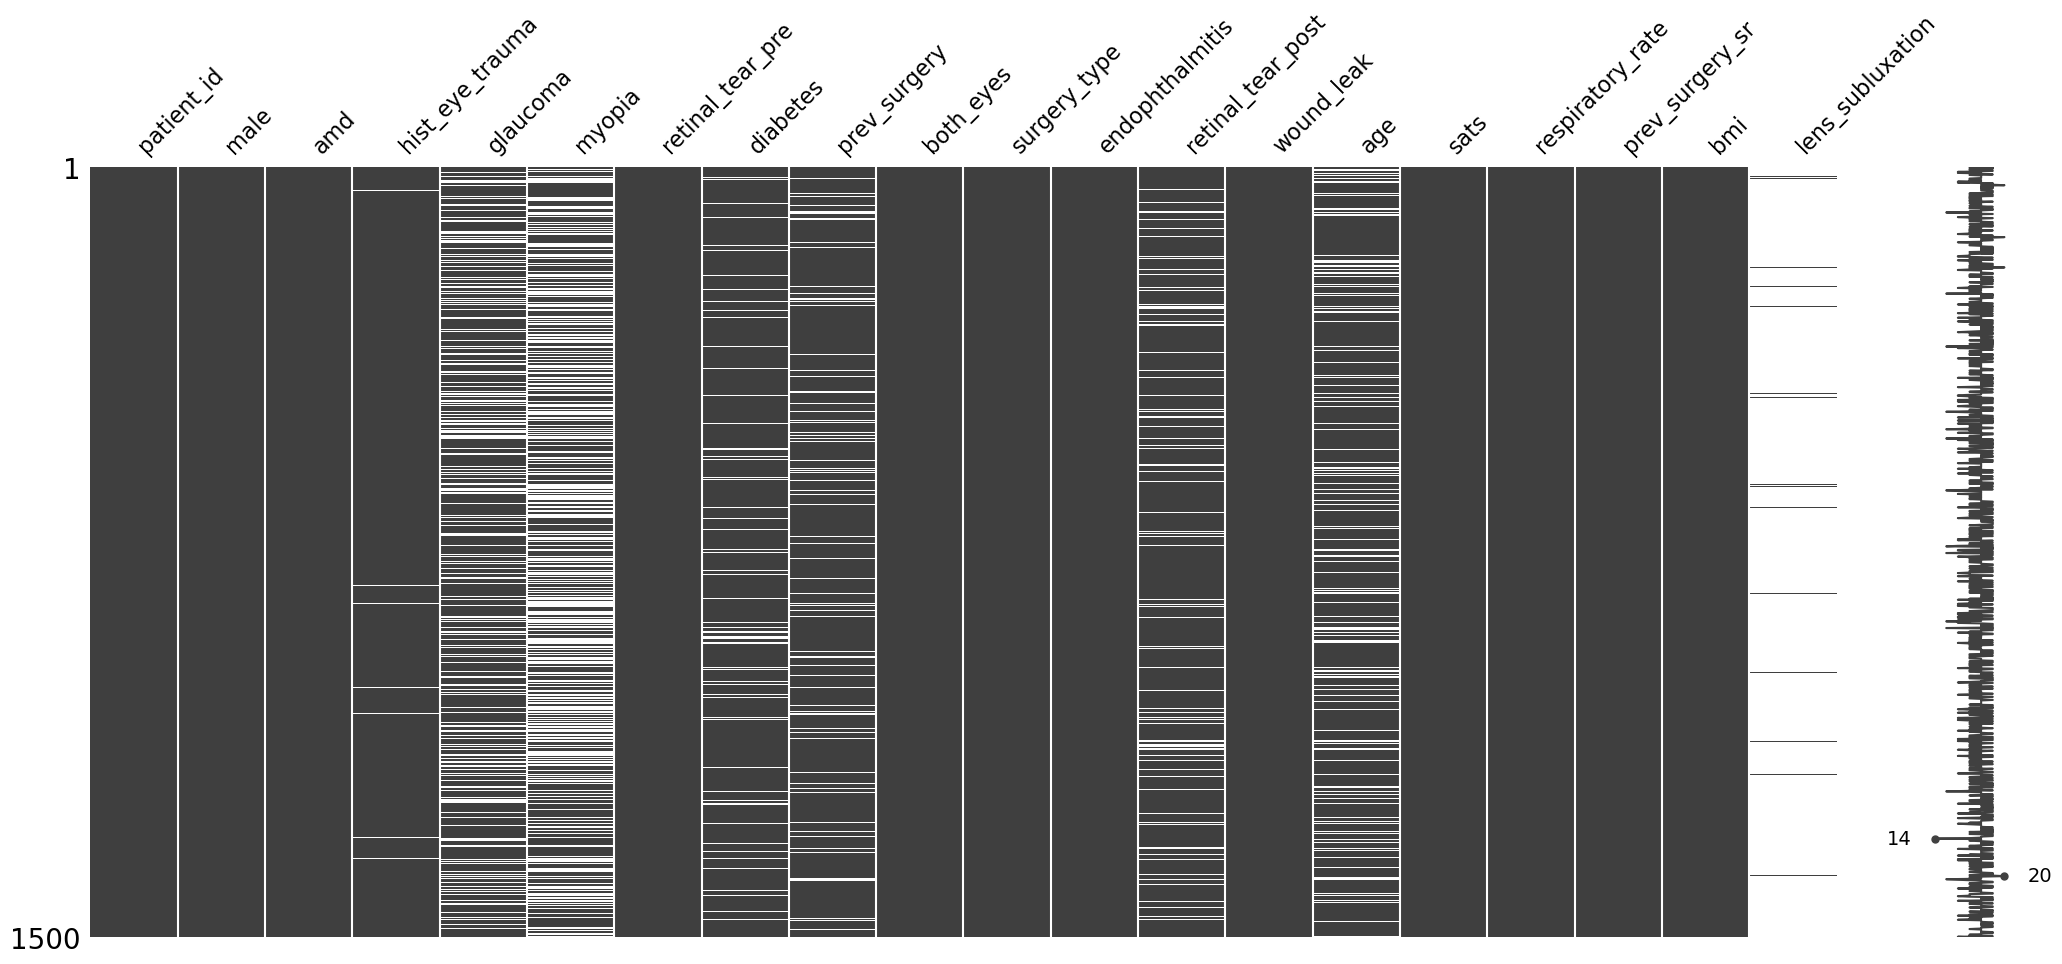

In [ ]:
# visualising missing data in the training set
import missingno as msno

msno.matrix(X_train)

# lens_sublaxation is almost completely missing, so will drop it from the training data
# hist_eye_trauma, glaucoma, myopia, diabetes, and prev_surgery are binary features
# age is a continuous feature
# these may need to be imputed differently 

<Axes: xlabel='discharge24'>

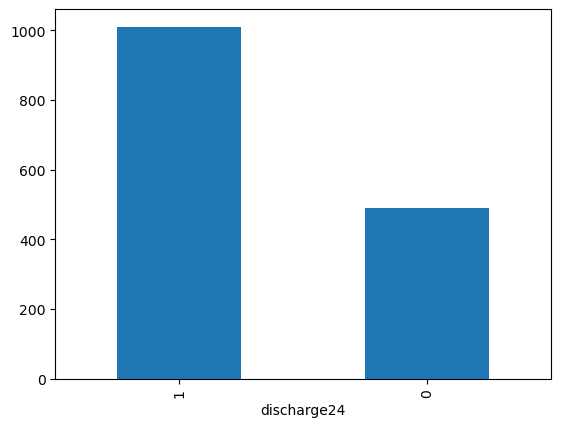

In [ ]:
# plotting the number of 1 vs 0 in y_train to check for class imbalance
y_train.value_counts().plot(kind='bar')

# there is some class imbalance but not extreme, and balanced accuracy will give equal weight to both classes

## Features to Drop

In [14]:
# endophtalmitis, retinal_tear_post, and wound_leak are all post-op future outcomes, so including them in the training data would cause temporal leakage
# patient_id also needs removing and lens_sublaxation as it is mostly missing, and bmi as we are creating the new overweight feature
# creating a function to drop these columns from the training data in the preprocessing pipeline
from sklearn.preprocessing import FunctionTransformer

def drop_columns(X):
    X = X.copy()
    return X.drop(columns=['patient_id', 'endophtalmitis', 'retinal_tear_post', 'wound_leak', 'lens_sublaxation'])

column_dropper = FunctionTransformer(drop_columns)

## Overweight BMI Binary Feature

In [15]:
# converting the BMI column into a binary overweight column where 1 is overweight and 0 is not overweight
def convert_bmi_to_overweight(X):
    X = X.copy()
    X['overweight'] = (X['bmi'] >= 25).astype(int)
    return X.drop(columns=['bmi'])

bmi_converter = FunctionTransformer(convert_bmi_to_overweight)

## Preprocessing Pipeline

In [16]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
# setting the output of transformations to be pandas dataframes
# this will ensure that after imputation/scaling, the output is still a pandas dataframe
from sklearn import set_config
set_config(transform_output="pandas") 

preprocessing_pipeline = make_pipeline(
    column_dropper,
    bmi_converter,
    SimpleImputer(strategy='median')
)

## Decision Tree Pipeline

In [17]:
# creating a pipeline for a decision tree model
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = make_pipeline(
    preprocessing_pipeline,
    DecisionTreeClassifier(random_state=1)
)

**You will not be able to run the code below as you do not have access to `y_test`**. 

In [ ]:
# do not run this code
y_test = pd.read_csv("y_test.csv")

balanced_accuracy = balanced_accuracy_score(y_true = y_test, y_pred = y_predict)

print(f'Final balanced accuracy: {balanced_accuracy:.6f}')